mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn, imbalanced-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.5425999999940396 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.2.25                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.11                          pyhd8ed1ab_0                  conda-forge                   
+ imbalanced-learn 

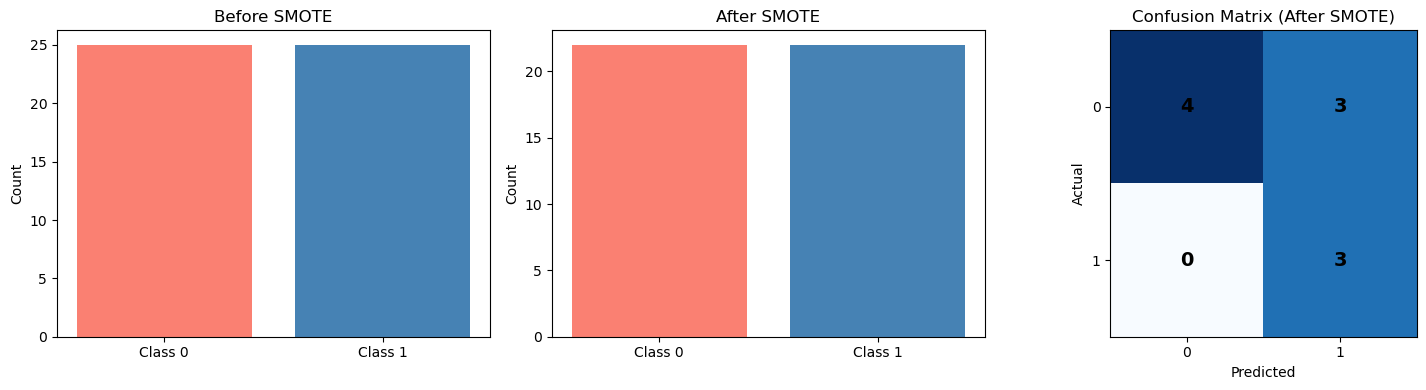

In [1]:
%matplotlib inline
!mamba install pandas scikit-learn numpy imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

df = pd.read_csv('exp5_50_Startups.csv')
print("Dataset:\n", df.head())
print("\nShape:", df.shape)

le = LabelEncoder()
df['State'] = le.fit_transform(df['State'])

df['ProfitClass'] = (df['Profit'] > df['Profit'].median()).astype(int)
df.drop('Profit', axis=1, inplace=True)

X = df.drop('ProfitClass', axis=1)
y = df['ProfitClass']

print("\nClass Distribution Before SMOTE:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42, k_neighbors=3)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("\nClass Distribution After SMOTE:")
print(pd.Series(y_resampled).value_counts())

model_before = LogisticRegression(max_iter=1000)
model_before.fit(X_train, y_train)
y_pred_before = model_before.predict(X_test)

model_after = LogisticRegression(max_iter=1000)
model_after.fit(X_resampled, y_resampled)
y_pred_after = model_after.predict(X_test)

print("\n--- Model Performance BEFORE SMOTE ---")
print(classification_report(y_test, y_pred_before))

print("--- Model Performance AFTER SMOTE ---")
print(classification_report(y_test, y_pred_after))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(['Class 0', 'Class 1'],
            [sum(y == 0), sum(y == 1)], color=['salmon', 'steelblue'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

axes[1].bar(['Class 0', 'Class 1'],
            [sum(y_resampled == 0), sum(y_resampled == 1)], color=['salmon', 'steelblue'])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')

cm = confusion_matrix(y_test, y_pred_after)
im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_title('Confusion Matrix (After SMOTE)')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_xticks([0, 1]); axes[2].set_yticks([0, 1])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()